Notebook to analyze convergence behavior of GCR on the $\mathcal F := PV^\dagger M$ operator with a $16^3\times 32$ config. Some things this notebook contains:
- Low-lying spectra
- Field of values of the operator
- Pseudospectra of the operator
- The field of values contains 0. I engineered a point source that caused complete stagnation of GCR, i.e., no convergence, by creating a vector $|s\rangle$ such that $\langle s | \mathcal F | s\rangle \approx 0$.

In [ ]:
%matplotlib ipympl

from ipywidgets import *

import sys
from time import time
import itertools
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colormaps
from mpl_toolkits.mplot3d import Axes3D, art3d

import os
import re
import glob

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 75

import xml.etree.ElementTree as ET
import h5py

from importlib import reload

sys.path.append('/Users/patrickoare/lqcd/utilities')
# import pytools as pyt
import plottools as pt
import formattools as fmt
pt.set_font()
default_style = fmt.styles['notebook']
default_style['colwidth'] = 12

import GCR
import utils

In [2]:
sty = default_style.copy()
sty['asp_ratio'] = 1.5
# sty['colwidth'] = 12 # for talk
sty['colwidth'] = 8
sty['fontsize'] = 24

### $PV^\dagger D_\ell$ on `ckpoint_lat.4000`

In [3]:
def parse_log(file, header = 'Level 1 PGCR step[', split_token = 'Fine Grid Smoother -- Level 2'):
    run = -1
    tokens = [x.strip() for x in file.split('\n')]
    resids = [[], []]           # [[Cheby resids], [KS resids]]
    with open(file) as f:
        lines = f.readlines()
        for token in lines:
            if split_token in token:
                run += 1
            if run < 0 or header not in token:
                continue
            resid = float(token.split('[')[1].split('resid ')[1].split(' target')[0])
            resids[run].append(resid)
    return resids

In [4]:
cheby_10, ks_10 = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_333941.log')
cg_20, ks_20 = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_334415.log')
cg_40, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_335010.log')
gcr_20, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_335405.log')
hdcg_40, _ = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_335553.log')
gcr_40, ks_40 = parse_log('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_337852.log')

In [5]:
def parse_output(estr):
    tokens = [x.strip() for x in estr.split('\n')]
    evals = []
    for token in tokens:
        if token == '': continue
        assert token[0] == '(' and token[-1] == ')', 'Wrong token input'
        token = token[1:-1].split(',')              # token == ['re', 'im']
        evals.append(
            float(token[0]) + 1j*float(token[1])
        )
    return evals

### Spectrum

In [6]:
pvdavm_evals = parse_output(r"""(0.00783777644,-2.18696589e-14)
 (0.00793712024,-0.00233563953)
  (0.00793712024,0.00233563953)
   (0.0079192746,0.00612062822)
  (0.0079192746,-0.00612062822)
  (0.00824646982,-0.0109907841)
   (0.00824646982,0.0109907841)
  (0.00861008307,-0.0122992181)
   (0.00861008307,0.0122992181)
    (0.00908786589,0.013649063)
   (0.00908786589,-0.013649063)
   (0.00901549137,0.0164975382)
  (0.00901549137,-0.0164975382)
  (0.00971712678,-0.0188641122)
   (0.00971712678,0.0188641122)
    (0.00932132839,-0.01917476)
     (0.00932132839,0.01917476)
   (0.0102084712,-0.0235018747)
    (0.0102084712,0.0235018747)
   (0.0101329536,-0.0243512003)
    (0.0101329536,0.0243512003)
    (0.0102828837,0.0251284544)
   (0.0102828837,-0.0251284544)
   (0.0106283517,-0.0279886586)
    (0.0106283517,0.0279886586)
     (0.0112557275,0.030825775)
    (0.0112557275,-0.030825775)
    (0.0121956012,0.0326433484)
   (0.0121946283,-0.0326450148)
   (0.0120972679,-0.0346510587)
    (0.0120972679,0.0346510587)
    (0.0132730519,0.0369533095)
   (0.0134104205,-0.0376077379)
    (0.0138048991,0.0400715052)
   (0.0138049731,-0.0400715091)
    (0.0145038971,0.0422109975)
   (0.0162247497,-0.0487128771)
    (0.0162248333,0.0487129126)
   (0.0185350722,-0.0561018352)
    (0.0185350813,0.0561018378)""")

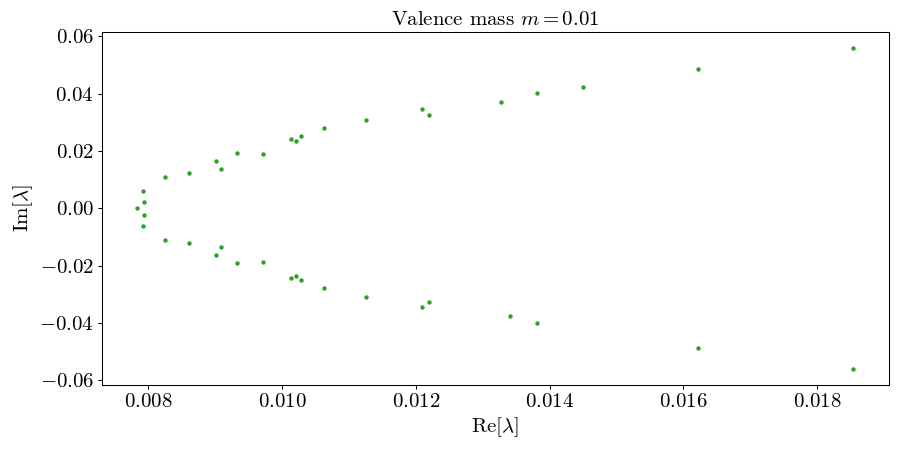

In [7]:
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(pvdavm_evals), np.imag(pvdavm_evals), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], title = r'Valence mass $m=0.01$', fn_label = r'$PV^\dagger M$')
# pt.add_line(ax, np.real(pvdavm_evals[20]), c = pt.pal[2], linestyle = '--')
# ax.legend(title = r'# evals', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
plt.tight_layout()
# pt.save_figure('/Users/patrickoare/Dropbox (Personal)/research/multigrid/columbia_seminar/pvdagm_spectra.pdf')

In [8]:
# read off nulliness for GCR
def read_nulliness(file, splitter = '<i|D|i>=', second_split = '; <i|DdagD|i>='):
    tokens = [x.strip() for x in file.split('\n')]
    nulliness = [[], []]           # [[<O>], [<O^\dagger O>]]
    # nulliness = []
    with open(file) as f:
        lines = f.readlines()
        for token in lines:
            if splitter in token:
                if second_split:
                    O, Osq = token.split(splitter)[1].split(second_split)
                    tmp = O[1:-1].split(',')
                    nulliness[0].append(float(tmp[0]) + 1j*float(tmp[1]))
                    nulliness[1].append(float(Osq))
                else:
                    O = token.split(splitter)[1]
                    tmp = O[1:-2].split(',')
                    nulliness[0].append(float(tmp[0]) + 1j*float(tmp[1]))
    return nulliness
# gcr_null, gcr_nullsq = read_nulliness('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_340843.log')
gcr_null = read_nulliness('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_341018.log')
cg_null = read_nulliness('/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/MG_PVdag_341072.log')

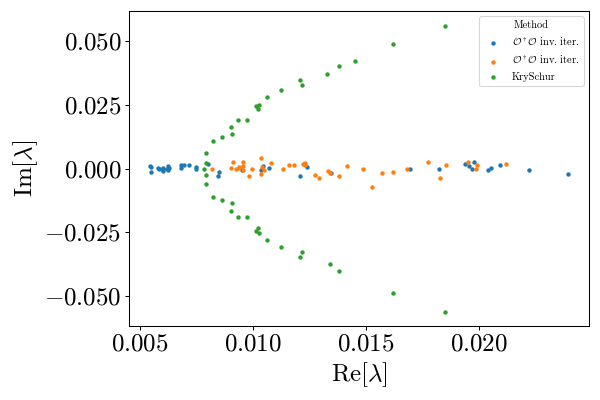

In [9]:
fig, axes = pt.add_subplots(style = sty)
ax = axes[0]
pt.scatter_1d(np.real(cg_null[0]), np.imag(cg_null[0]), ax = ax, col = pt.pal[0], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'$\mathcal{O}^\dagger\mathcal{O}$ inv. iter.', style = sty)
pt.scatter_1d(np.real(gcr_null[0]), np.imag(gcr_null[0]), ax = ax, col = pt.pal[1], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'$\mathcal{O}^\dagger\mathcal{O}$ inv. iter.', style = sty)
pt.scatter_1d(np.real(pvdavm_evals), np.imag(pvdavm_evals), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'KrySchur', style = sty)
# ax.legend(title = 'Method', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
ax.legend(title = 'Method', bbox_to_anchor=(1, 1))
# ax.set_title(r'Deflation basis nulliness $\langle k | \mathcal{O} |k\rangle$ ($\mathcal{O} := PV^\dagger M$)', fontsize = sty['fontsize'])
plt.tight_layout()
# pt.save_figure('/Users/patrickoare/Dropbox (Personal)/research/multigrid/lattice_2026/figs/mg_nulliness.pdf')

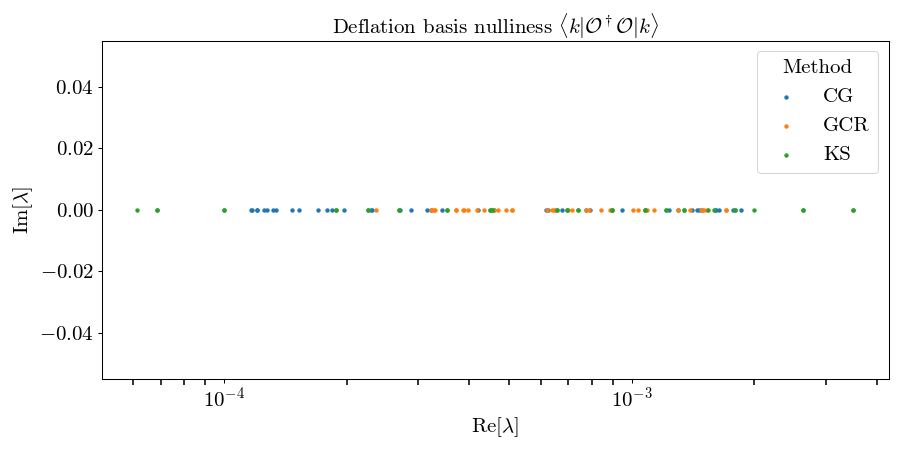

In [10]:
fig, axes = pt.add_subplots()
ax = axes[0]
pt.scatter_1d(np.real(cg_null[1]), np.imag(cg_null[1]), ax = ax, col = pt.pal[0], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'CG')
pt.scatter_1d(np.real(gcr_null[1]), np.imag(gcr_null[1]), ax = ax, col = pt.pal[1], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'GCR')
pt.scatter_1d(np.abs(pvdavm_evals)**2, 0*np.imag(pvdavm_evals), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'KS')
ax.legend(title = 'Method', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
ax.set_title(r'Deflation basis nulliness $\langle k | \mathcal{O}^\dagger\mathcal{O} |k\rangle$', fontsize = default_style['fontsize'])
ax.set_xscale('log')
plt.tight_layout()

### Field of Values

In [11]:
fov_dir = f'/Users/patrickoare/lqcd/multigrid/pseudospectra/fov/ckpoint_lat.4000/PVdagM_fov_Nang17_theta30_madj1_390884/'
def read_fov(dir, dtype=np.complex128):
    d = np.loadtxt(os.path.join(dir, "fov_left.txt"), comments="#", ndmin=2)
    return (d[:, 3] + 1j * d[:, 4]).astype(dtype)
fov = read_fov(fov_dir)

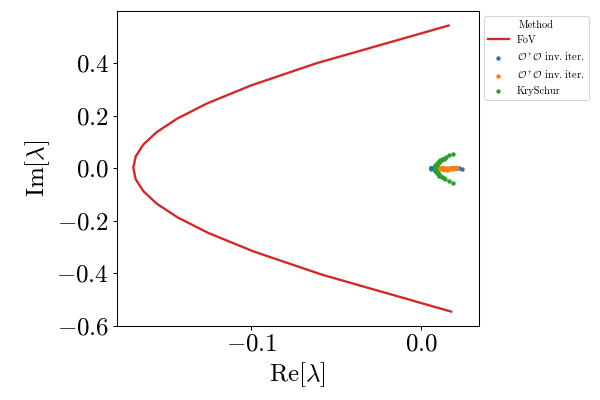

In [12]:
fig, axes = pt.add_subplots(style = sty)
ax = axes[0]
pt.plot_1d_data(np.real(fov), np.imag(fov), ax = ax, col = pt.pal[3], fn_label = 'FoV', style = sty)
pt.scatter_1d(np.real(cg_null[0]), np.imag(cg_null[0]), ax = ax, col = pt.pal[0], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'$\mathcal{O}^\dagger\mathcal{O}$ inv. iter.', style = sty)
pt.scatter_1d(np.real(gcr_null[0]), np.imag(gcr_null[0]), ax = ax, col = pt.pal[1], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'$\mathcal{O}^\dagger\mathcal{O}$ inv. iter.', style = sty)
pt.scatter_1d(np.real(pvdavm_evals), np.imag(pvdavm_evals), ax = ax, col = pt.pal[2], ax_label = [r'$\mathrm{Re}[\lambda]$', r'$\mathrm{Im}[\lambda]$'], fn_label = r'KrySchur', style = sty)
# ax.legend(title = 'Method', title_fontsize = default_style['fontsize'], fontsize = default_style['fontsize'], bbox_to_anchor=(1, 1))
ax.legend(title = 'Method', bbox_to_anchor=(1, 1))
# ax.set_title(r'Deflation basis nulliness $\langle k | \mathcal{O} |k\rangle$ ($\mathcal{O} := PV^\dagger M$)', fontsize = sty['fontsize'])
plt.tight_layout()
# pt.save_figure('/Users/patrickoare/Dropbox (Personal)/research/multigrid/plots/fov_pvdagm_16cube.pdf')

### Pseudospectrum

In [21]:
reload(ps)

<module 'pseudospectra' from '/Users/patrickoare/lqcd/multigrid/python_scripts/pseudospectra.py'>

In [20]:
import pseudospectra as ps

ps_dir = "/Users/patrickoare/lqcd/multigrid/pseudospectra/PVdagMps_Nm100_Nk50_Niter10000_392675"
R, b, meta = ps.read_ks(ps_dir)
print(ps.check_ks(R, b, meta))          # [] means clean

# re = np.linspace(-0.02, 0.08, 251)
# im = np.linspace(-0.16, 0.16, 251)
# re = np.linspace(-0.1, 0.08, 501)
# im = np.linspace(-0.5, 0.5, 501)
re = np.linspace(-0.2, 0.2, 1001)
im = np.linspace(-0.6, 0.6, 1001)
# re, im = ps.make_grid(R)                 # or build your own linspaces
S = ps.smin_grid(R, b, re, im)           # S[i,j] = s(re[j] + i*im[i])

[]


In [15]:
np.max(S)

0.523402272279797

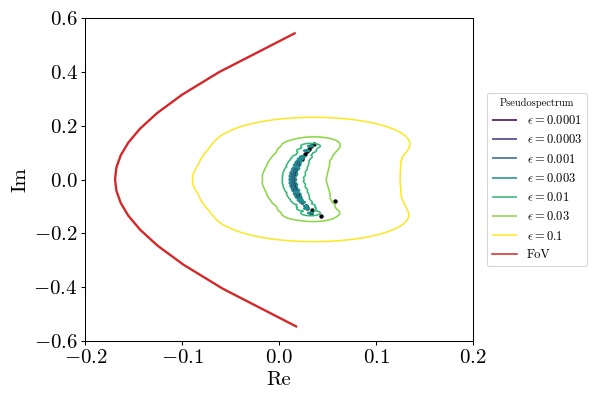

In [16]:
fig, axes = pt.add_subplots(style = sty)
ax = axes[0]
# ax.contour(re, im, np.log10(S), levels=np.arange(-4, 0.5, 0.5), cmap = 'viridis')

eps = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
cs = ax.contour(re, im, S, levels=eps, norm=mpl.colors.LogNorm(), cmap="viridis")

handles, _ = cs.legend_elements()
labels = [rf"$\epsilon = {v:g}$" for v in cs.levels]

pt.plot_1d_data(np.real(fov), np.imag(fov), ax = ax, col = pt.pal[3], fn_label = 'FoV', style = sty)
handles.append(mpl.lines.Line2D([], [], color=pt.pal[3], lw=1.5))
labels += ["FoV"]

rv = pt.scatter_1d(np.linalg.eigvals(R).real, np.linalg.eigvals(R).imag, ax = ax, col = 'k', fn_label = 'Ritz', ax_label=['Re', 'Im'])

ax.set_xlim((-0.2, 0.2))

# plt.legend()
ax.legend(handles, labels, title = 'Pseudospectrum', loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=12)
fig.tight_layout()
plt.show()

# plt.savefig('/Users/patrickoare/Dropbox (Personal)/research/multigrid/plots/ckpoint_lat.4000/PVdagM/ps_50Ritz.pdf')

### Engineered stagnation vector

In [23]:
stag_path_no_restart = r'/Users/patrickoare/lqcd/multigrid/logs/ckpoint_lat.4000/PVdagM_stagnate_Nang17_theta30_madj1_nstep1_394217.log'

# Banner text identifying each solve, mapped to the key returned.
_SECTIONS = [
    ("engineered", re.compile(r"GCR ON THE ENGINEERED SOURCE")),
    ("control",    re.compile(r"GCR ON THE SAME-SUBSPACE CONTROL")),
    ("random",     re.compile(r"GCR ON A RANDOM SOURCE")),
]
_STEP = re.compile(r"PGCR step\[(\d+)\]\s+resid\s+([0-9eE.+-]+)")

def read_stagnate(path):
    """Residual histories from an Example_pvdagm_stagnate log.

    `path` may be the log file itself or a directory containing exactly one *.log.
    Returns (engineered, control, random) as float arrays of the printed `resid`,
    which is ||r||^2 relative to the source -- take sqrt for the residual norm.
    A solve absent from the log (older runs predate the control) comes back empty.
    """
    if os.path.isdir(path):
        logs = sorted(glob.glob(os.path.join(path, "*.log")))
        if len(logs) != 1:
            raise ValueError("expected exactly one *.log in %s, found %d" % (path, len(logs)))
        path = logs[0]

    out = {key: [] for key, _ in _SECTIONS}
    current = None
    with open(path) as f:
        for line in f:
            for key, pat in _SECTIONS:
                if pat.search(line):
                    current = key
                    break
            else:
                m = _STEP.search(line)
                if m is not None and current is not None:
                    out[current].append(float(m.group(2)))

    return tuple(np.array(out[key]) for key, _ in _SECTIONS)

In [24]:
stag, ctrl, random = read_stagnate(stag_path_no_restart)

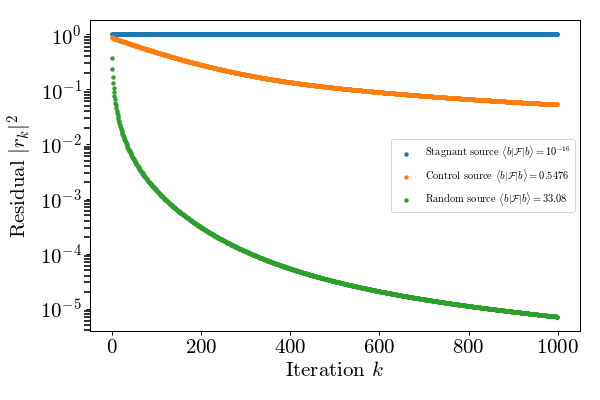

In [25]:
iters = list(range(len(stag)))

fig, axes = pt.add_subplots(style = sty)
ax = axes[0]
pt.scatter_1d(iters, stag, col = pt.pal[0], ax = ax, fn_label = r'Stagnant source $\langle b|\mathcal{F}|b\rangle = 10^{-16}$', ax_label = [r'Iteration $k$', r'Residual $|r_k|^2$'])
pt.scatter_1d(iters, ctrl, col = pt.pal[1], ax = ax,  fn_label = r'Control source $\langle b|\mathcal{F}|b\rangle = 0.5476$', ax_label = [r'Iteration $k$', r'Residual $|r_k|^2$'])
pt.scatter_1d(iters, random, col = pt.pal[2], ax = ax, fn_label = r'Random source $\langle b|\mathcal{F}|b\rangle = 33.08$', ax_label = [r'Iteration $k$', r'Residual $|r_k|^2$'])

plt.legend()
ax.set_yscale('log')
plt.show()